# CHURN PROJECT(BY Animesh Sandhu)

### AIM : Predict whether a customer will churn to help the bank reduce customer loss.

##### Data Description:

    1. `Customer ID`: A unique identifier for each customer

    2. `Surname`: The customer's surname or last name

    3. `Credit Score`: A numerical value representing the customer's credit score

    4. `Geography`: The country where the customer resides

    5. `Gender`: The customer's gender

    6. `Age`: The customer's age.

    7. `Tenure`: The number of years the customer has been with the bank

    8. `Balance`: The customer's account balance

    9. `NumOfProducts`: The number of bank products the customer uses (e.g., savings account, credit card)

    10. `HasCrCard`: Whether the customer has a credit card

    11. `IsActiveMember`: Whether the customer is an active member

    12. `EstimatedSalary`: The estimated salary of the customer

    13. `Exited`: Whether the customer has churned (Target Variable)

1. numerical columns
    * Credit score
    * age
    * tenure
    * balance
    * num of products
    * estimated salary

2. Categorical columns
    * Geography
    * Gendre

3. Binary Features
    * Hascrcard
    * isactivememeber
    * exited


In [1]:
# import libaries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as py

In [3]:
# importing dataset
df = pd.read_csv("churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [6]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [11]:
# target variable insight
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

The dataset is imbalanced, with a higher proportion of non-churn customers compared to churn customers

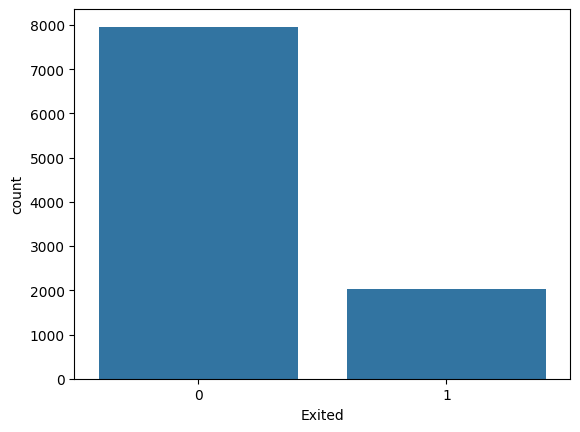

In [12]:
sns.countplot(x= 'Exited', data=df)
plt.show()

0 = not churn\
1 = churn

Why do customers leave?\
What features could influence churn?

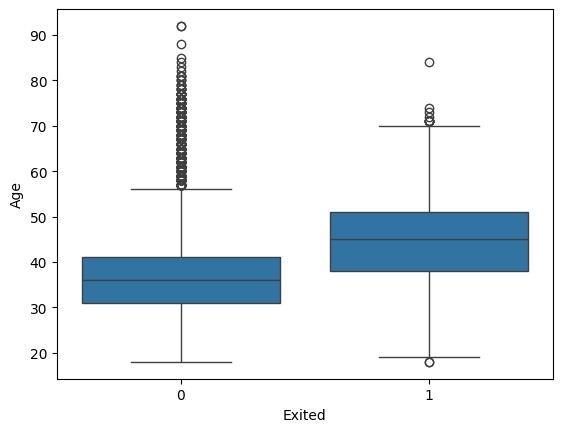

In [14]:
sns.boxplot(x='Exited', y= 'Age', data=df)
plt.show()

Customers who churn tend to be older compared to those who stay, suggesting age is positively associated with churn.

Interpretation:
* Younger customers = stay
* Older customers = more likely to leave

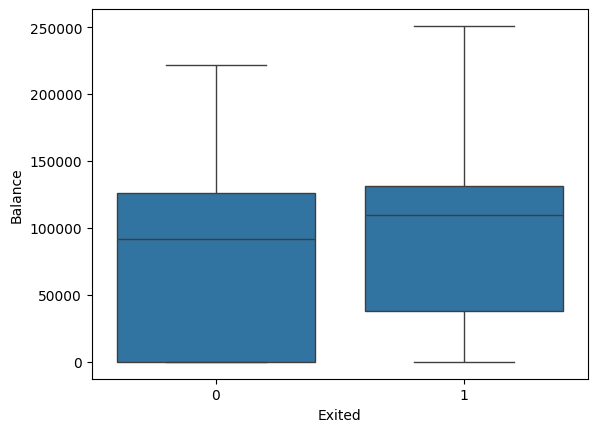

In [15]:
sns.boxplot(x= 'Exited', y = 'Balance', data = df)
plt.show()

Customers with higher balances show a higher tendency to churn, while a large portion of non-churn customers have zero balance

`Interpretation`:

High balance customers: 
* More valuable
* More likely to switch banks

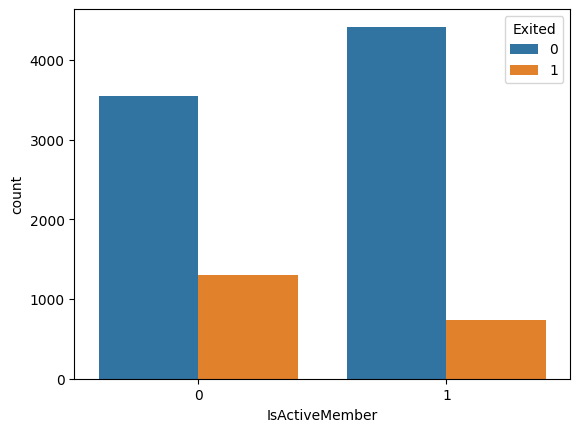

In [16]:
sns.countplot(x = 'IsActiveMember', hue='Exited',data = df)
plt.show()

* 0 = inactive
* 1 = active
* Blue = not churn
* Orange = churn

Inactive customers (0): High churn count

Active customers (1): Much lower churn

Inactive customers are significantly more likely to churn compared to active customers

`Interpretation`:\
Activity = engagement\
Engagement = retention

## hypothesis testing(exited and age)
* Null Hypothesis (H0):

“There is NO difference in age between churned and non-churned customers"

* Alternative Hypothesis (H1):

“There IS a significant difference in age between churned and non-churned customers.”


In [18]:
from scipy.stats import ttest_ind

churn_age = df[df['Exited'] == 1]['Age']
not_churn_age = df[df['Exited']== 0]['Age']

t_stat, p_value = ttest_ind(churn_age,not_churn_age)

print("T-stats", t_stat)
print("p-value",p_value)

T-stats 29.76681499437077
p-value 1.2399313093427934e-186


In [19]:
# confidence interval

import scipy.stats as stats

data = churn_age

mean = np.mean(data)
sem = stats.sem(data)

ci = stats.t.interval(0.95,len(data)-1, loc = mean , scale = sem)

print("mean age(churn):",mean)
print("95% CI:",ci)

mean age(churn): 44.8379970544919
95% CI: (np.float64(44.41383664660602), np.float64(45.26215746237778))


“A two-sample t-test was conducted to compare the age of churned and non-churned customers. The results showed a highly statistically significant difference (p < 0.05), indicating that age plays a crucial role in customer churn. The mean age of churned customers is approximately 44.8 years, with a 95% confidence interval between 44.4 and 45.3, suggesting that older customers are more likely to leave the bank.”

## hypothesis testing(exited and isactivemember)

* Null Hypothesis (H0):

“IsActiveMember and churn (Exited) are independent.”

* Alternative Hypothesis (H1):

“IsActiveMember and churn are related.”


In [27]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['IsActiveMember'],df['Exited'])

chi2, p_value, dof , expected = chi2_contingency(table)

print("chi-square:",chi2)
print("p-value:", p_value)
print("contingency_tabel:",table)

chi-square: 242.98534164287963
p-value: 8.785858269303705e-55
contingency_tabel: Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735


In [28]:
table_pct = table.div(table.sum(axis=1), axis=0)
print(table_pct)

Exited                 0         1
IsActiveMember                    
0               0.731491  0.268509
1               0.857309  0.142691


"A chi-square test of independence was conducted to examine the relationship between customer activity status and churn. The results showed a highly statistically significant association (p < 0.05), indicating that these variables are not independent. The churn rate among inactive customers is approximately 26.8%, compared to 14.3% for active customers, suggesting that inactive customers are nearly twice as likely to churn. This highlights customer engagement as a critical factor in retention.”

“Customer engagement (IsActiveMember) is one of the strongest predictors of churn and can be directly targeted through retention strategies.”

## feature engineering

In [30]:
df['BalanceSalaryRatio'] = df['Balance']/ (df['EstimatedSalary']+1)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035


In [31]:
df['TenureGroup'] = pd.cut(df['Tenure'],bins=[0,3,6,10],labels=['New','Mid','old'])

In [32]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,45,60,100],
                        labels=['Young','Adult','Senior','Old'])

In [33]:
df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

In [34]:
df['ActiveBalance'] = df['IsActiveMember'] * df['Balance']

In [35]:
df['CreditScoreGroup'] = pd.cut(df['CreditScore'],
                                bins =[300,500,650,750,900],
                                labels=['Low','Medium','Good','Excellent'])

<Axes: xlabel='Exited', ylabel='BalanceSalaryRatio'>

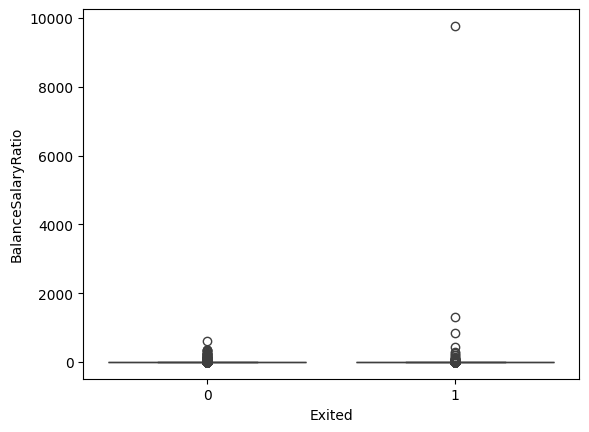

In [36]:
sns.boxplot(x='Exited',y='BalanceSalaryRatio',data=df)

<Axes: xlabel='TenureGroup', ylabel='count'>

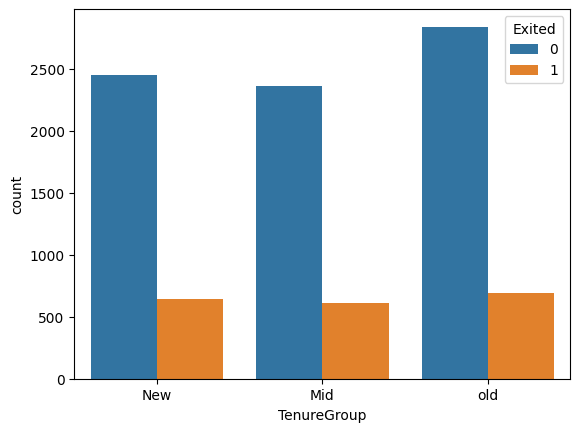

In [37]:
sns.countplot(x='TenureGroup', hue= 'Exited',data=df)

<Axes: xlabel='AgeGroup', ylabel='count'>

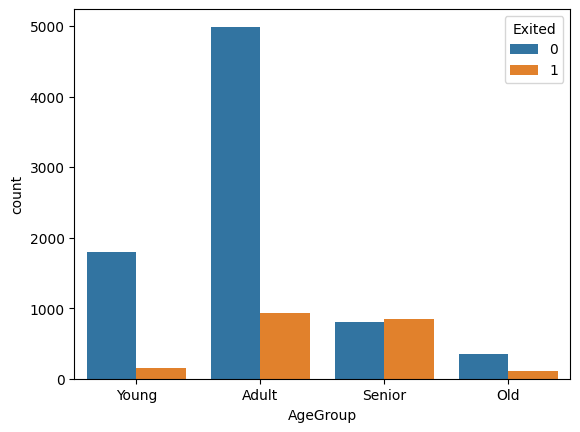

In [38]:
sns.countplot(x= 'AgeGroup', hue= 'Exited', data = df)

<Axes: xlabel='Exited', ylabel='ProductsPerTenure'>

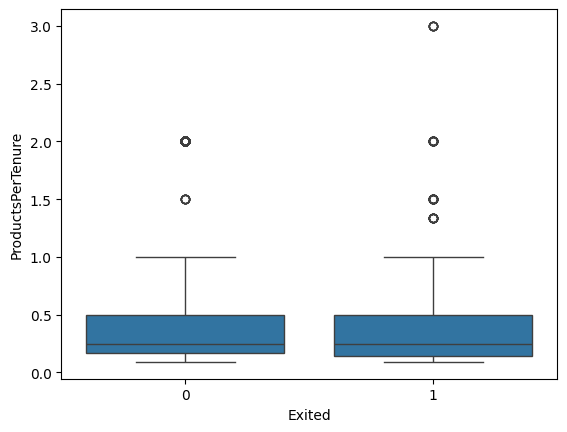

In [39]:
sns.boxplot(x='Exited', y= 'ProductsPerTenure',data= df)

<Axes: xlabel='Exited', ylabel='ActiveBalance'>

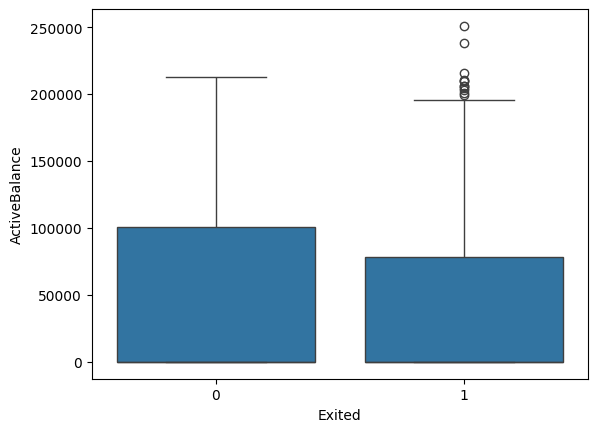

In [40]:
sns.boxplot(x='Exited',y = 'ActiveBalance', data=df)

In [41]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureGroup,AgeGroup,ProductsPerTenure,ActiveBalance,CreditScoreGroup
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,New,Adult,0.333333,0.00,Medium
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,New,Adult,0.500000,83807.86,Medium
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,old,Adult,0.333333,0.00,Medium
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,New,Adult,1.000000,0.00,Good
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,New,Adult,0.333333,125510.82,Excellent


In [43]:
df.drop('TenureGroup',axis=1,inplace=True)
df.drop('ProductsPerTenure',axis=1,inplace=True)
df.drop('ActiveBalance',axis=1,inplace=True)

Churn rate increases significantly with age group, with senior customers exhibiting the highest churn rates, indicating age segmentation is an important predictor.\
Products per tenure does not show a clear distinction between churned and non-churned customers, suggesting limited predictive importance

In [47]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,AgeGroup,CreditScoreGroup
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,Adult,Medium
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,Adult,Medium
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,Adult,Medium
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,Adult,Good
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,Adult,Excellent


In [48]:
df['BalanceSalaryRatio_log'] = np.log1p(df['BalanceSalaryRatio']) 

In [50]:
df.drop('BalanceSalaryRatio',axis=1,inplace=True)

In [53]:
df.drop('Surname',axis=1,inplace=True)
df.drop('CustomerId',axis=1,inplace=True)
df.drop('RowNumber',axis=1,inplace=True)

# Machine Learning model

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   CreditScore             10000 non-null  int64   
 1   Geography               10000 non-null  str     
 2   Gender                  10000 non-null  str     
 3   Age                     10000 non-null  int64   
 4   Tenure                  10000 non-null  int64   
 5   Balance                 10000 non-null  float64 
 6   NumOfProducts           10000 non-null  int64   
 7   HasCrCard               10000 non-null  int64   
 8   IsActiveMember          10000 non-null  int64   
 9   EstimatedSalary         10000 non-null  float64 
 10  Exited                  10000 non-null  int64   
 11  AgeGroup                9978 non-null   category
 12  CreditScoreGroup        10000 non-null  category
 13  BalanceSalaryRatio_log  10000 non-null  float64 
dtypes: category(2), float64(3), int64(

In [56]:
num_features = [
    'CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary',
    'Tenure',
    'NumOfProducts',
    'BalanceSalaryRatio_log'
]
cat_features = [
    'Geography',
    'Gender',
    'AgeGroup',
    'CreditScoreGroup'
]
bin_features = [
    'HasCrCard',
    'IsActiveMember'
]


In [62]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers =[
        ('num',StandardScaler(),num_features),
        ('cat',OneHotEncoder(drop='first'),cat_features),
        ('bin','passthrough',bin_features)
    ]
)

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('model',RandomForestClassifier(class_weight='balanced',random_state=42))
])

In [94]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [95]:
from sklearn.metrics import classification_report
y_prob = pipeline.predict_proba(X_test)[:,1]
y_pred_new = (y_prob>0.3).astype(int)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test,y_pred_new))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1607
           1       0.58      0.65      0.61       393

    accuracy                           0.84      2000
   macro avg       0.74      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



“I adjusted the decision threshold from 0.5 to 0.3 to improve recall for churn prediction. This increased the model’s ability to identify at-risk customers from 45% to 65%, which is more valuable from a business perspective, even though it slightly reduced precision.”

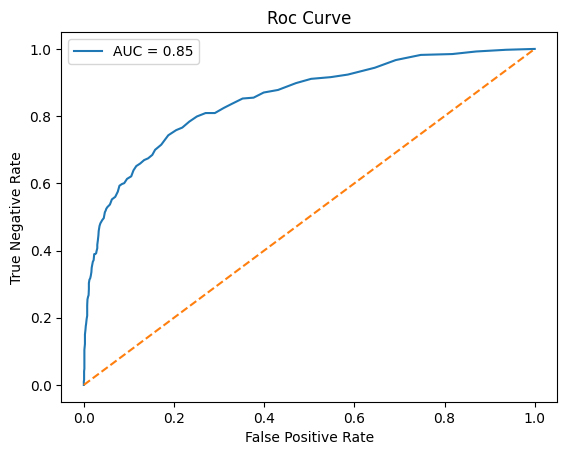

In [76]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label = f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Negative Rate")
plt.title("Roc Curve")
plt.legend()
plt.show()

“The model achieves an AUC of 0.85, indicating strong ability to distinguish between churned and non-churned customers. Additionally, lift analysis shows that the model can identify high-risk customers nearly five times better than random selection, making it highly effective for targeted retention strategies.”

In [79]:
# lift 

df_eval = pd.DataFrame({
    'y_true':y_test,
    'y_prob': y_prob
})


In [80]:
df_eval = df_eval.sort_values(by='y_prob',ascending=False)

In [82]:
df_eval['decile'] = pd.cut(df_eval['y_prob'],10,labels=False)

In [85]:
lift_table = df_eval.groupby('decile').agg(
    total =('y_true','count'),
    churn =('y_true','sum')
)

lift_table['churn_rate'] = lift_table['churn'] / lift_table['total']
baseline = df_eval['y_true'].mean()
lift_table['lift'] = lift_table['churn_rate']/baseline
print(lift_table.sort_index(ascending=False))

        total  churn  churn_rate      lift
decile                                    
9          12     11    0.916667  4.664970
8          45     42    0.933333  4.749788
7          61     50    0.819672  4.171359
6          63     43    0.682540  3.473484
5          52     34    0.653846  3.327461
4          84     37    0.440476  2.241609
3         143     42    0.293706  1.494689
2         224     49    0.218750  1.113232
1         425     45    0.105882  0.538841
0         891     40    0.044893  0.228465


“The model achieves a lift of approximately 4.7 in the top decile, meaning it identifies high-risk customers nearly five times better than random selection. In the highest risk segment, over 90% of customers are likely to churn, enabling highly effective targeted retention strategies.”

# grid cv search

In [86]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5],
}

In [96]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',  # VERY IMPORTANT for churn
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [97]:
best_model = grid.best_estimator_

print(grid.best_params_)

{'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [98]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.83      0.87      1607
           1       0.51      0.73      0.60       393

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [90]:
y_prob = best_model.predict_proba(X_test)[:,1]

for t in [0.5, 0.4, 0.3]:
    y_pred = (y_prob > t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_test, y_pred))
    print("-"*40)

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.83      0.87      1607
           1       0.51      0.73      0.60       393

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

----------------------------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      1607
           1       0.36      0.86      0.51       393

    accuracy                           0.68      2000
   macro avg       0.66      0.75      0.63      2000
weighted avg       0.83      0.68      0.71      2000

----------------------------------------
Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.37      0.54      1607
           1       0.27      0.95      0.42       393

    accuracy                           0.48      2000
 

“I optimized the model using GridSearchCV with recall as the scoring metric to prioritize identifying churn customers. The tuned model achieved a recall of 73%, significantly improving over the baseline. I also experimented with threshold tuning, but found that the tuned model already provided a good balance between recall and precision at the default threshold.”

In [102]:
import joblib

joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']